# Un probiótico que solo trabaja cuando el azúcar sube

Cinco monos diabéticos tomaron una bacteria modificada durante 34 días. La glucosa en ayunas les bajó un 30,3%.

Y aun así no volvieron a estar sanos.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Guan et al. (2026). *Glucose-responsive probiotics for glycaemic modulation in mice and monkeys*. Nature.
**DOI:** [10.1038/s41586-026-10909-6](https://doi.org/10.1038/s41586-026-10909-6)
**Datos:** Source Data del propio paper (Figs. 1, 3 y 5 + Extended Data Fig. 8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-12-probioticos-glucosa-diabetes/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/AkbPcNil1lM)

## Qué hicieron

Tomaron *Escherichia coli* Nissle — una bacteria que ya se vende como probiótico — y le metieron un circuito genético: un regulador que reacciona a la glucosa (HexR) enganchado a un promotor sintético. Traducido: un interruptor que lee cuánta azúcar hay alrededor.

Cuando el azúcar pasa cierto nivel, el interruptor se cierra y la bacteria fabrica GLP-1, la hormona que le dice al páncreas que suelte insulina. Cuando el azúcar vuelve a su sitio, se apaga. La bacteria se toma por la boca, pasa un rato por el intestino y sale — no hay trasplante ni cirugía.

Lo probaron en ratones y en monos. **En personas no**: eso está en el título del paper.

Abrimos los datos que el equipo publicó junto al artículo y miramos tres cosas: si el sensor de verdad distingue niveles de azúcar, si reacciona a comida real, y qué tanto bajó la glucosa de los monos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_ACTIVACION_mM = 10      # Donde el sensor se dispara (Fig. 1c)
GLUCOSA_SANOS_mM = 5.07        # Media de los monos no diabéticos (Fig. 5h)
DIA_INICIO_TRATAMIENTO = 1     # Día 0 y anteriores = basal
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'
FUENTE = 'Fuente: Guan et al. (2026), Nature | Datos: Source Data del propio paper'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo editorial CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga ──
sensor = pd.read_csv('datos/sensor_dosis_respuesta.csv')
revers = pd.read_csv('datos/sensor_reversibilidad.csv')
comida = pd.read_csv('datos/comida_real_glucemia.csv')
monos = pd.read_csv('datos/monos_glucemia_ayunas.csv')
ogtt = pd.read_csv('datos/monos_ogtt.csv')
auc = pd.read_csv('datos/monos_auc.csv')

# Etiquetas con tildes (los CSV vienen sin acentuar)
TILDES = {'Cola dietetica': 'Cola dietética', 'Pienso estandar': 'Pienso estándar',
          'PBS': 'Solución salina',  # PBS = suero fisiológico tamponado, el control sin azúcar
          'Diabeticos GIFT-GLP-1': 'Diabéticos tratados',
          'Diabeticos sin tratar': 'Diabéticos sin tratar',
          'No diabeticos': 'No diabéticos', 'Despues': 'Después'}
comida['alimento'] = comida['alimento'].replace(TILDES)
monos['grupo'] = monos['grupo'].replace(TILDES)
ogtt['fase'] = ogtt['fase'].replace(TILDES)
auc['fase'] = auc['fase'].replace(TILDES)

print(f'Sensor en tubo:      {len(sensor):>3} filas | {sensor.glucosa_mM.nunique()} concentraciones x 3 réplicas')
print(f'Encendido/apagado:   {len(revers):>3} filas | 2 secuencias x 12 h')
print(f'Comida real (ratón): {len(comida):>3} filas | {comida.alimento.nunique()} alimentos, n=6 por grupo')
print(f'Monos en ayunas:     {len(monos):>3} filas | 3 grupos x 5 monos | tratados: 15 días, controles: 7')
print(f'Prueba de azúcar:    {len(ogtt):>3} filas | 5 monos, antes y después')
print(f'Área bajo la curva:  {len(auc):>3} filas | 5 monos, pareado')

Sensor en tubo:       21 filas | 7 concentraciones x 3 réplicas
Encendido/apagado:    72 filas | 2 secuencias x 12 h
Comida real (ratón): 150 filas | 5 alimentos, n=6 por grupo
Monos en ayunas:     145 filas | 3 grupos x 5 monos | tratados: 15 días, controles: 7
Prueba de azúcar:     50 filas | 5 monos, antes y después
Área bajo la curva:   10 filas | 5 monos, pareado


## El sensor

Aquí está.

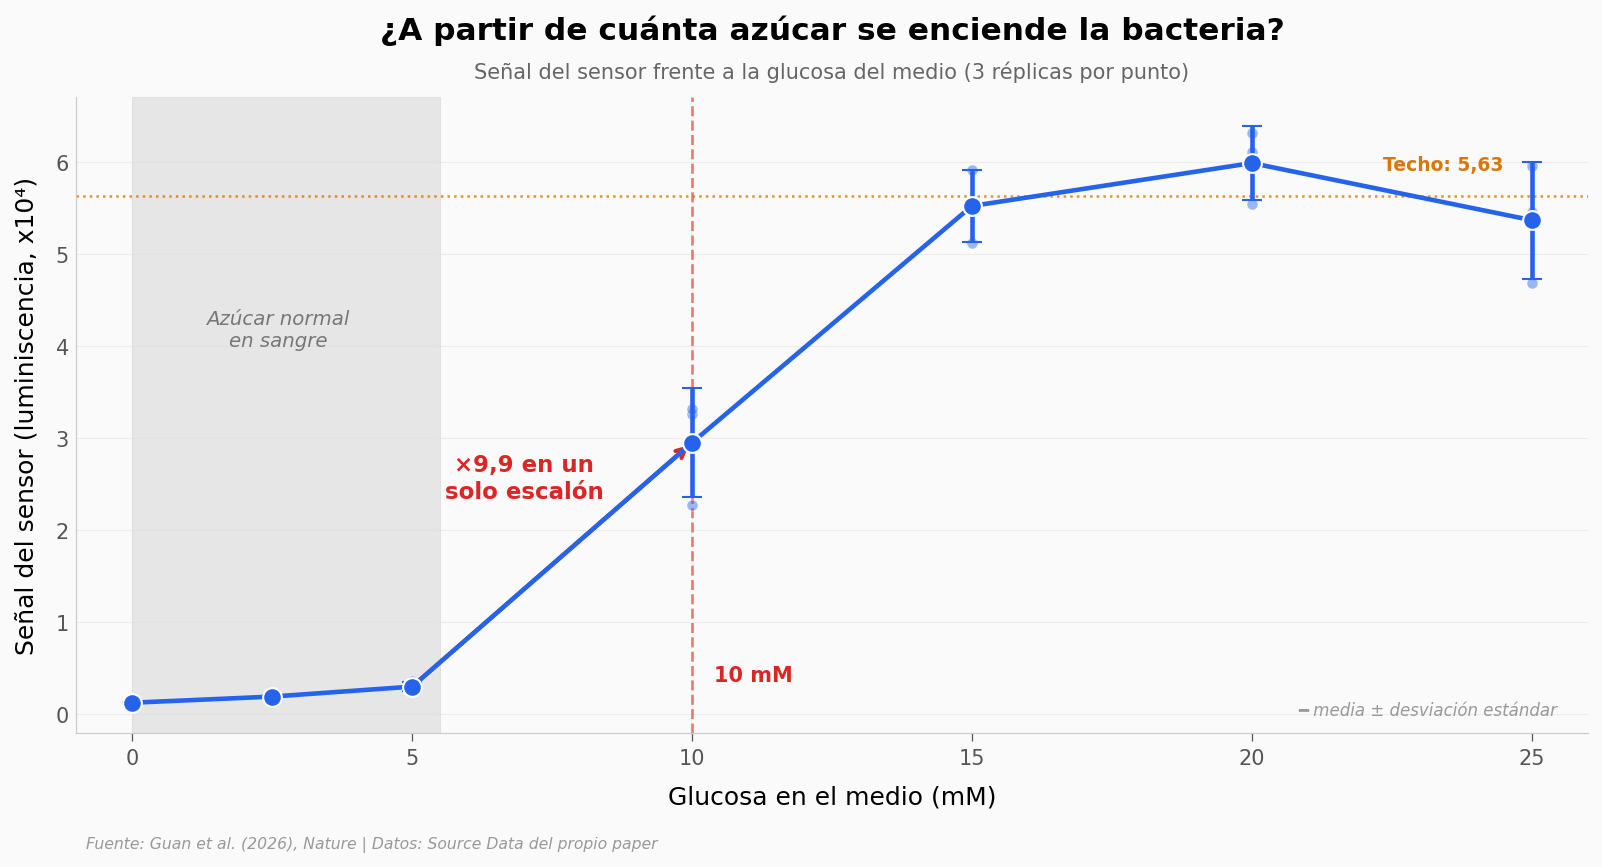

Correlación de rangos (Spearman): rho = 0.916, p = 5.58e-09  (n = 21)
El escalón 5 -> 10 mM: d de Cohen = 6.33, t de dos muestras p = 0.0015  (3 réplicas por punto)
Salto de 5 a 10 mM: x9.88   |   Máximo (20 mM) frente a 0 mM: x48.6


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

res = sensor.groupby('glucosa_mM').luminiscencia_x1e4.agg(['mean', 'std', 'count'])

# Zona de glucosa normal en sangre (referencia visual)
ax.axvspan(0, 5.5, color=COLOR_CONTEXTO, alpha=0.30, zorder=0)
ax.text(2.6, 4.4, 'Azúcar normal\nen sangre', fontsize=9.5, color='#777777',
        ha='center', va='top', style='italic')

ax.errorbar(res.index, res['mean'], yerr=res['std'], fmt='o-', color=COLOR_DATOS,
            markersize=9, linewidth=2.2, capsize=5, capthick=1.5,
            markeredgecolor='white', markeredgewidth=1, zorder=5)
ax.scatter(sensor.glucosa_mM, sensor.luminiscencia_x1e4, color=COLOR_DATOS,
           s=28, alpha=0.45, edgecolors='white', linewidths=0.5, zorder=4)

# El salto
salto = res.loc[10, 'mean'] / res.loc[5, 'mean']
ax.annotate('', xy=(10, res.loc[10, 'mean']), xytext=(5, res.loc[5, 'mean']),
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=2))
ax.text(7.0, 2.35, f'×{salto:.1f} en un\nsolo escalón'.replace('.', ','), fontsize=11,
        fontweight='bold', color=COLOR_ALERTA, ha='center')

ax.axvline(x=UMBRAL_ACTIVACION_mM, color=COLOR_ALERTA, linewidth=1.3,
           linestyle='--', alpha=0.6)
ax.text(UMBRAL_ACTIVACION_mM + 0.4, 0.35, f'{UMBRAL_ACTIVACION_mM} mM',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

meseta = res.loc[[15, 20, 25], 'mean'].mean()
ax.axhline(y=meseta, color=COLOR_REFERENCIA, linewidth=1.2, linestyle=':', alpha=0.8)
ax.text(24.5, meseta + 0.28, f'Techo: {meseta:.2f}'.replace('.', ','), fontsize=9,
        color=COLOR_REFERENCIA, ha='right', fontweight='bold')

ax.set_title('¿A partir de cuánta azúcar se enciende la bacteria?',
             fontsize=15, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Señal del sensor frente a la glucosa del medio (3 réplicas por punto)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Glucosa en el medio (mM)')
ax.set_ylabel('Señal del sensor (luminiscencia, x10⁴)')
ax.set_xlim(-1, 26)
ax.text(0.98, 0.02, '━ media ± desviación estándar', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sensor_umbral.png', dpi=200, bbox_inches='tight')
plt.show()

rho, p = stats.spearmanr(sensor.glucosa_mM, sensor.luminiscencia_x1e4)
print(f'Correlación de rangos (Spearman): rho = {rho:.3f}, p = {p:.2e}  (n = {len(sensor)})')
v5 = sensor[sensor.glucosa_mM == 5].luminiscencia_x1e4
v10 = sensor[sensor.glucosa_mM == 10].luminiscencia_x1e4
sp = np.sqrt(((len(v5) - 1) * v5.std(ddof=1) ** 2 + (len(v10) - 1) * v10.std(ddof=1) ** 2) / (len(v5) + len(v10) - 2))
print(f'El escalón 5 -> 10 mM: d de Cohen = {(v10.mean() - v5.mean()) / sp:.2f}, '
      f't de dos muestras p = {stats.ttest_ind(v10, v5).pvalue:.4f}  (3 réplicas por punto)')
print(f'Salto de 5 a 10 mM: x{salto:.2f}   |   Máximo (20 mM) frente a 0 mM: x{res.loc[20, "mean"] / res.loc[0, "mean"]:.1f}')

### No es un dial: es un interruptor

Lo que llama la atención no es que suba, es *cómo* sube. Entre 0 y 5 mM la bacteria está prácticamente muda: pasa de 0,123 a 0,299. En el escalón siguiente, de 5 a 10 mM, salta a 2,951 — casi diez veces más con solo cinco unidades de diferencia (d de Cohen = 6,3; t de dos muestras p = 0,0015, con 3 réplicas por punto).

Y después deja de importar. Desde 15 mM la señal se planta en un techo de 5,63 y ahí se queda: a 25 mM no hay más respuesta que a 15. Más azúcar ya no compra más señal.

Eso es exactamente lo que uno querría de un dispositivo así. Un sensor proporcional soltaría un poco de hormona todo el tiempo, incluso con el azúcar normal. Este se queda callado en la zona sana y se despierta cuando la cosa se sale de rango.

La correlación de rangos es alta (ρ = 0,916), pero el número que cuenta la historia es el escalón, no la pendiente.

Falta la otra mitad del asunto: un interruptor que se enciende y no se apaga sirve de poco.

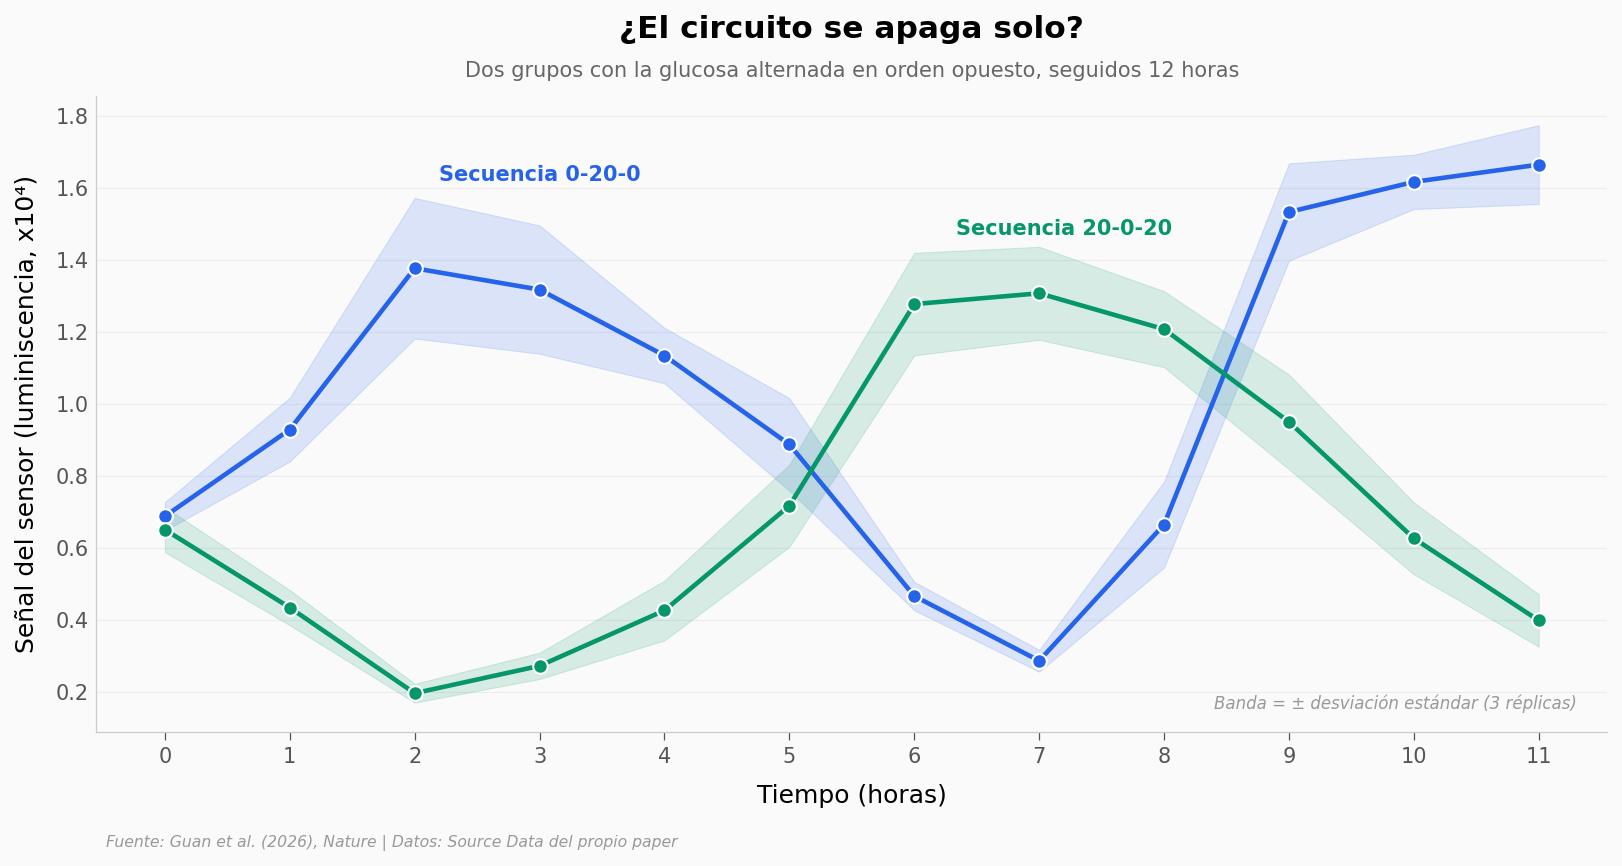

Las dos secuencias van en espejo: rho = -0.699, p = 0.0114  (n = 12 horas)
Rango recorrido — 0-20-0: 0.287 a 1.665  |  20-0-20: 0.197 a 1.307


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

piv = revers.groupby(['tiempo_h', 'secuencia_glucosa_mM']).luminiscencia_x1e4.agg(['mean', 'std'])
colores = {'0-20-0': COLOR_DATOS, '20-0-20': COLOR_SECUNDARIO}

for seq, color in colores.items():
    sub = piv.xs(seq, level='secuencia_glucosa_mM')
    ax.plot(sub.index, sub['mean'], 'o-', color=color, markersize=7,
            linewidth=2.2, markeredgecolor='white', markeredgewidth=1, zorder=5)
    ax.fill_between(sub.index, sub['mean'] - sub['std'], sub['mean'] + sub['std'],
                    color=color, alpha=0.15, zorder=2)

ax.text(3.0, 1.62, 'Secuencia 0-20-0', fontsize=10, color=COLOR_DATOS,
        fontweight='bold', ha='center')
ax.text(7.2, 1.47, 'Secuencia 20-0-20', fontsize=10, color=COLOR_SECUNDARIO,
        fontweight='bold', ha='center')

ax.set_title('¿El circuito se apaga solo?', fontsize=15, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Dos grupos con la glucosa alternada en orden opuesto, seguidos 12 horas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tiempo (horas)')
ax.set_ylabel('Señal del sensor (luminiscencia, x10⁴)')
ax.set_xticks(range(0, 12))
ax.text(0.98, 0.03, 'Banda = ± desviación estándar (3 réplicas)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sensor_reversibilidad.png', dpi=200, bbox_inches='tight')
plt.show()

a = piv.xs('0-20-0', level='secuencia_glucosa_mM')['mean']
b = piv.xs('20-0-20', level='secuencia_glucosa_mM')['mean']
rho_r, p_r = stats.spearmanr(a, b)
print(f'Las dos secuencias van en espejo: rho = {rho_r:.3f}, p = {p_r:.4f}  (n = 12 horas)')
print(f'Rango recorrido — 0-20-0: {a.min():.3f} a {a.max():.3f}  |  20-0-20: {b.min():.3f} a {b.max():.3f}')

### Sube y baja, no se queda pegado

Las dos curvas se persiguen al revés: cuando una está arriba, la otra está abajo (ρ = −0,699, p = 0,0114). Ninguna se queda clavada en su máximo. El circuito no es un fusible que se quema una vez — vuelve.

Una honestidad acá: el pie de figura de este panel está tras el muro de pago, así que **no podemos decir qué hora exacta llevaba azúcar y cuál no**. Lo que los datos sí sostienen es la relación en espejo entre las dos secuencias y que la señal regresa a valores bajos. El cronograma preciso se nos queda del otro lado.

Hasta aquí todo pasa en un tubo, con glucosa pura y en cantidades que el experimentador escoge. La pregunta obvia es qué hace esto frente a comida de verdad.

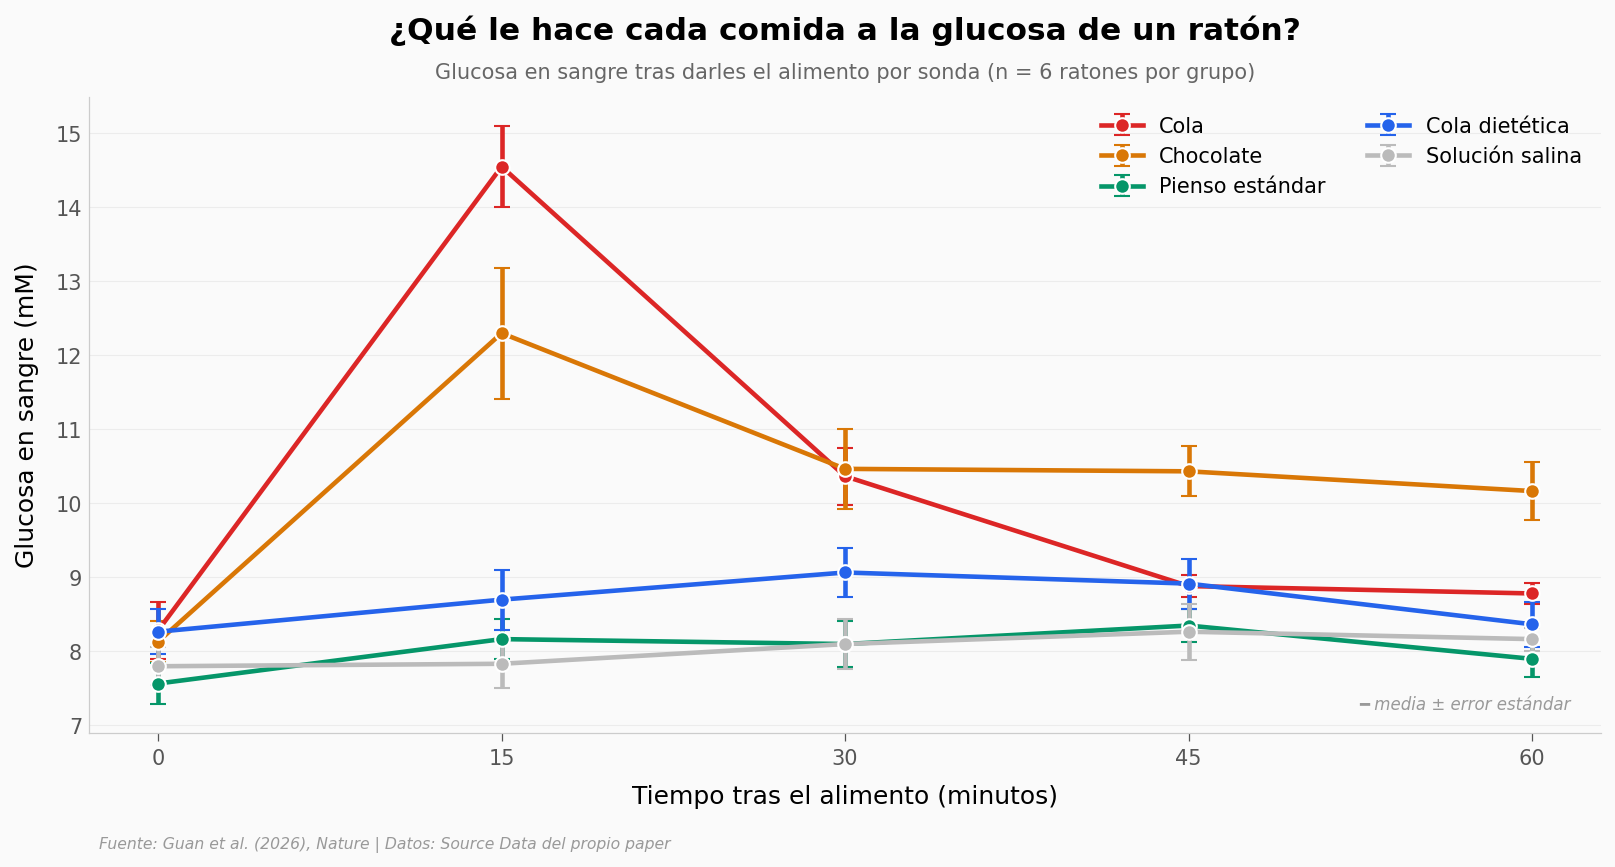

Alimento             basal   15 min   cambio    d de Cohen   p (Mann-Whitney)
Cola                  8.28    14.55    +6.27          6.11             0.0022
Chocolate             8.13    12.30    +4.17          2.74             0.0022
Pienso estándar       7.57     8.17    +0.60          0.46             0.6273
Cola dietética        8.27     8.70    +0.43          0.97             0.1275
Solución salina       7.80     7.83    +0.03    referencia                   


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

CONTROL = 'Solución salina'
orden = ['Cola', 'Chocolate', 'Pienso estándar', 'Cola dietética', CONTROL]
paleta = {'Cola': COLOR_ALERTA, 'Chocolate': COLOR_REFERENCIA,
          'Pienso estándar': COLOR_SECUNDARIO, 'Cola dietética': COLOR_DATOS,
          CONTROL: COLOR_CONTEXTO}

for alim in orden:
    sub = comida[comida.alimento == alim].groupby('tiempo_min').glucosa_mM.agg(['mean', 'sem'])
    ax.errorbar(sub.index, sub['mean'], yerr=sub['sem'], fmt='o-', color=paleta[alim],
                markersize=7, linewidth=2.2, capsize=4, capthick=1.2,
                markeredgecolor='white', markeredgewidth=1, label=alim, zorder=5)

ax.legend(fontsize=10, loc='upper right', framealpha=0.9, ncol=2)
ax.set_title('¿Qué le hace cada comida a la glucosa de un ratón?',
             fontsize=15, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Glucosa en sangre tras darles el alimento por sonda (n = 6 ratones por grupo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tiempo tras el alimento (minutos)')
ax.set_ylabel('Glucosa en sangre (mM)')
ax.set_xticks([0, 15, 30, 45, 60])
ax.text(0.98, 0.03, '━ media ± error estándar', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comida_real.png', dpi=200, bbox_inches='tight')
plt.show()

pbs15 = comida[(comida.tiempo_min == 15) & (comida.alimento == CONTROL)].glucosa_mM
print(f'{"Alimento":<18}{"basal":>8}{"15 min":>9}{"cambio":>9}{"d de Cohen":>14}{"p (Mann-Whitney)":>19}')
for alim in orden:
    basal = comida[(comida.tiempo_min == 0) & (comida.alimento == alim)].glucosa_mM.mean()
    v15 = comida[(comida.tiempo_min == 15) & (comida.alimento == alim)].glucosa_mM
    if alim == CONTROL:
        print(f'{alim:<18}{basal:>8.2f}{v15.mean():>9.2f}{v15.mean() - basal:>+9.2f}'
              f'{"referencia":>14}{"":>19}')
        continue
    sp = np.sqrt(((len(v15) - 1) * v15.std(ddof=1) ** 2 +
                  (len(pbs15) - 1) * pbs15.std(ddof=1) ** 2) / (len(v15) + len(pbs15) - 2))
    d = (v15.mean() - pbs15.mean()) / sp
    p = stats.mannwhitneyu(v15, pbs15).pvalue
    print(f'{alim:<18}{basal:>8.2f}{v15.mean():>9.2f}{v15.mean() - basal:>+9.2f}{d:>14.2f}{p:>19.4f}')

### El azúcar es el azúcar

A los 15 minutos, la Coca-Cola sube la glucosa de 8,28 a 14,55 mM: **+6,27 mM**, con un tamaño de efecto enorme frente al control (d = 6,11). El chocolate hace lo suyo, +4,17 mM (d = 2,74).

La versión dietética sube 0,43 mM y no se separa del control: p = 0,1275, o sea que la diferencia cabe dentro del ruido de seis ratones. El pienso normal, igual (p = 0,6273). El edulcorante pasa sin dejar rastro en la glucosa; los carbohidratos, no.

Un detalle sobre el tamaño de la muestra: son seis ratones por grupo. Con seis animales, un valor de p bajo es compatible con un efecto grande, pero no permite afinar *cuánto* exactamente — con muestras así de pequeñas, lo que alcanza a salir significativo tiende además a exagerar la magnitud. Los efectos que vemos acá son lo bastante grandes para no depender de eso.

Ya sabemos que el sensor tiene un umbral, que se apaga, y que la comida real lo pondría a trabajar. Falta lo que de verdad importa: darle el probiótico a un animal enfermo y ver si le baja el azúcar.

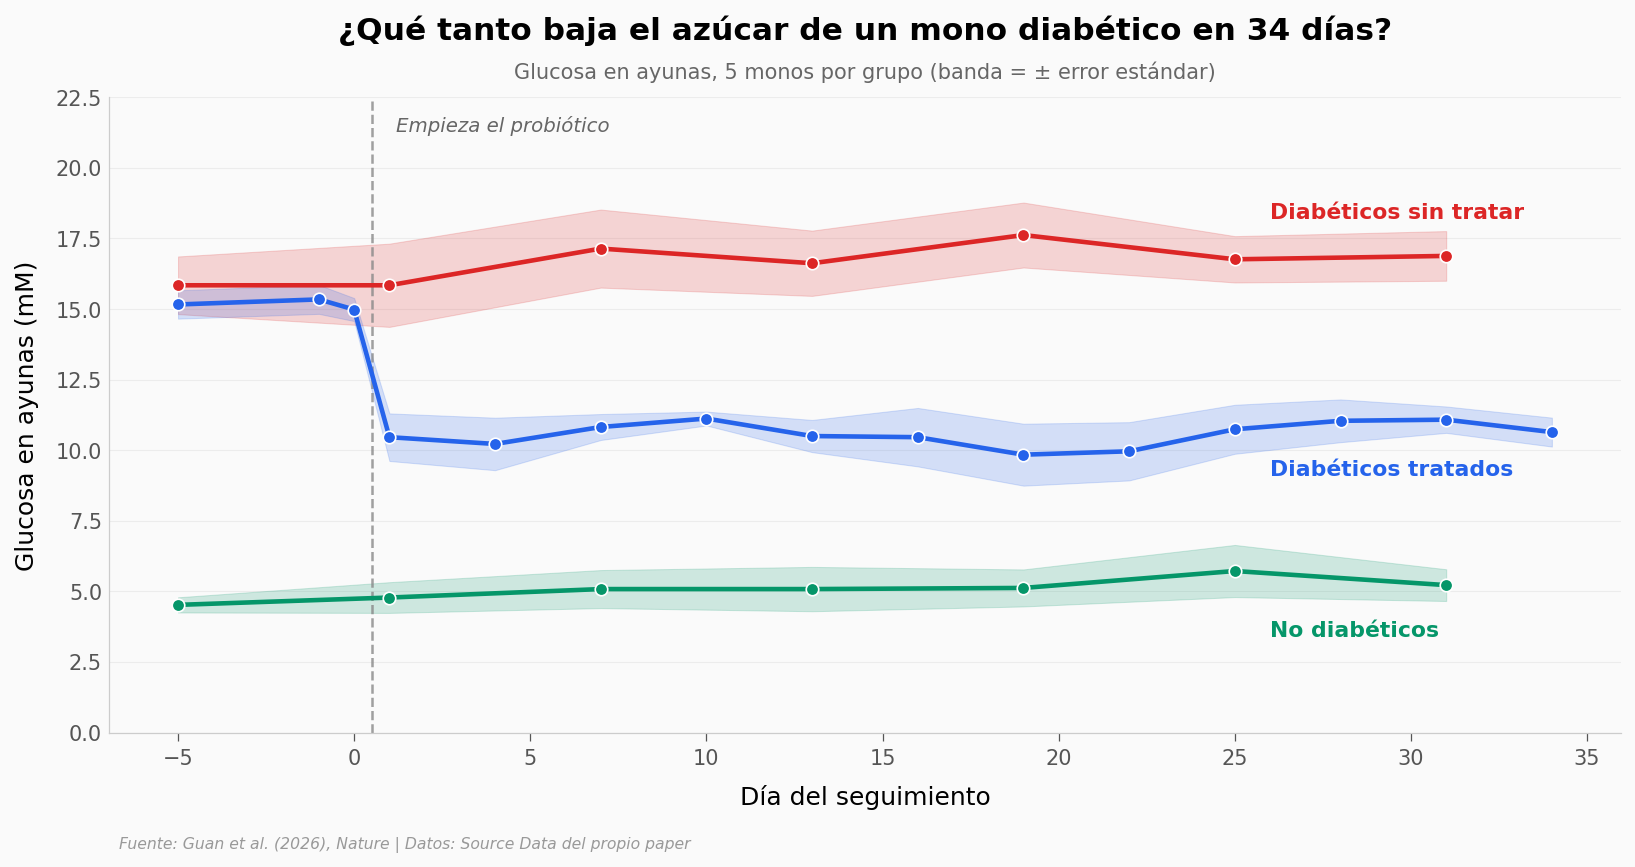

Los mismos 5 monos, antes y durante (comparación pareada):
  Basal (días -5 a 0):      15.16 mM
  Tratamiento (días 1-34):  10.57 mM
  Cambio: -4.59 mM (-30.3%)
  Cambio por mono: -3.62, -5.62, -6.53, -2.02, -5.16 mM  ->  5/5 bajan
  d de Cohen pareado = 2.58
  t pareado p = 0.0045  |  Wilcoxon p = 0.0625 (mínimo posible con n=5: 0,0625)

  Monos no diabéticos: 5.07 mM  ->  brecha que queda: 5.50 mM


In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

estilo = {'Diabéticos sin tratar': (COLOR_ALERTA, 'Diabéticos sin tratar'),
          'Diabéticos tratados': (COLOR_DATOS, 'Diabéticos tratados'),
          'No diabéticos': (COLOR_SECUNDARIO, 'No diabéticos')}

for grupo, (color, etiqueta) in estilo.items():
    sub = monos[monos.grupo == grupo].groupby('dia').glucosa_mM.agg(['mean', 'sem'])
    ax.plot(sub.index, sub['mean'], 'o-', color=color, markersize=6, linewidth=2.2,
            markeredgecolor='white', markeredgewidth=0.8, zorder=5)
    ax.fill_between(sub.index, sub['mean'] - sub['sem'], sub['mean'] + sub['sem'],
                    color=color, alpha=0.18, zorder=2)

# Inicio del tratamiento
ax.axvline(x=0.5, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(1.2, 21.3, 'Empieza el probiótico', fontsize=9.5, color='#666666', style='italic')

# Inline labels
ax.text(26, 18.2, 'Diabéticos sin tratar', fontsize=10.5, color=COLOR_ALERTA, fontweight='bold')
ax.text(26, 9.1, 'Diabéticos tratados', fontsize=10.5, color=COLOR_DATOS, fontweight='bold')
ax.text(26, 3.4, 'No diabéticos', fontsize=10.5, color=COLOR_SECUNDARIO, fontweight='bold')

ax.set_title('¿Qué tanto baja el azúcar de un mono diabético en 34 días?',
             fontsize=15, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Glucosa en ayunas, 5 monos por grupo (banda = ± error estándar)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Día del seguimiento')
ax.set_ylabel('Glucosa en ayunas (mM)')
ax.set_ylim(0, 22.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/monos_34_dias.png', dpi=200, bbox_inches='tight')
plt.show()

trat = monos[monos.grupo == 'Diabéticos tratados']
basal = trat[trat.dia <= 0].groupby('mono').glucosa_mM.mean()
durante = trat[trat.dia >= DIA_INICIO_TRATAMIENTO].groupby('mono').glucosa_mM.mean()
dif = durante - basal
sanos = monos[monos.grupo == 'No diabéticos'].glucosa_mM.mean()

print(f'Los mismos 5 monos, antes y durante (comparación pareada):')
print(f'  Basal (días -5 a 0):      {basal.mean():.2f} mM')
print(f'  Tratamiento (días 1-34):  {durante.mean():.2f} mM')
print(f'  Cambio: {dif.mean():+.2f} mM ({100 * dif.mean() / basal.mean():+.1f}%)')
print(f'  Cambio por mono: {", ".join(f"{x:+.2f}" for x in dif.values)} mM  ->  {(dif < 0).sum()}/5 bajan')
print(f'  d de Cohen pareado = {abs(dif.mean() / dif.std(ddof=1)):.2f}')
print(f'  t pareado p = {stats.ttest_rel(durante, basal).pvalue:.4f}  |  '
      f'Wilcoxon p = {stats.wilcoxon(durante, basal).pvalue:.4f} (mínimo posible con n=5: 0,0625)')
print(f'\n  Monos no diabéticos: {sanos:.2f} mM  ->  brecha que queda: {durante.mean() - sanos:.2f} mM')

### Bajan mucho. No se curan.

Los cinco monos bajan, sin excepción: −3,62, −5,62, −6,53, −2,02 y −5,16 mM. La media pasa de 15,16 a 10,57 mM, un descenso de 4,59 mM (−30,3%) con un tamaño de efecto grande (d pareado = 2,58).

Ahora la parte que ninguna nota de prensa pone en el titular. Los monos sanos de este mismo experimento están en 5,07 mM. Los tratados terminan en 10,57. Quedan **5,50 mM por encima** — más del doble del valor sano. Recorrieron menos de la mitad del camino.

Conviene mirar los cinco por separado antes de quedarse con la media. Cuatro de ellos bajan el área bajo la curva entre un 29% y un 37%; el quinto apenas se mueve, un 4%. El "5 de 5" es cierto en dirección, pero no todos responden igual.

Sobre los valores de p, vale la pena mirar de cerca: el t pareado da 0,0045, pero el Wilcoxon da 0,0625. No se contradicen. Con cinco animales, 0,0625 es el valor **más bajo que el Wilcoxon puede producir** — aunque los cinco bajaran muchísimo, ese test no puede bajar de ahí. Por eso reportamos el t pareado — el mismo test que el paper usa en el área bajo la curva (Tabla S16, Fig. 5j). Para la glucosa en ayunas la tabla estadística del paper no lista ningún test: ese p = 0,0045 es cálculo nuestro. La señal acá no está en el p: está en que los 5 de 5 se mueven en la misma dirección y en la magnitud del efecto.

Falta cerrar con la prueba estándar: darles azúcar y ver cómo la manejan.

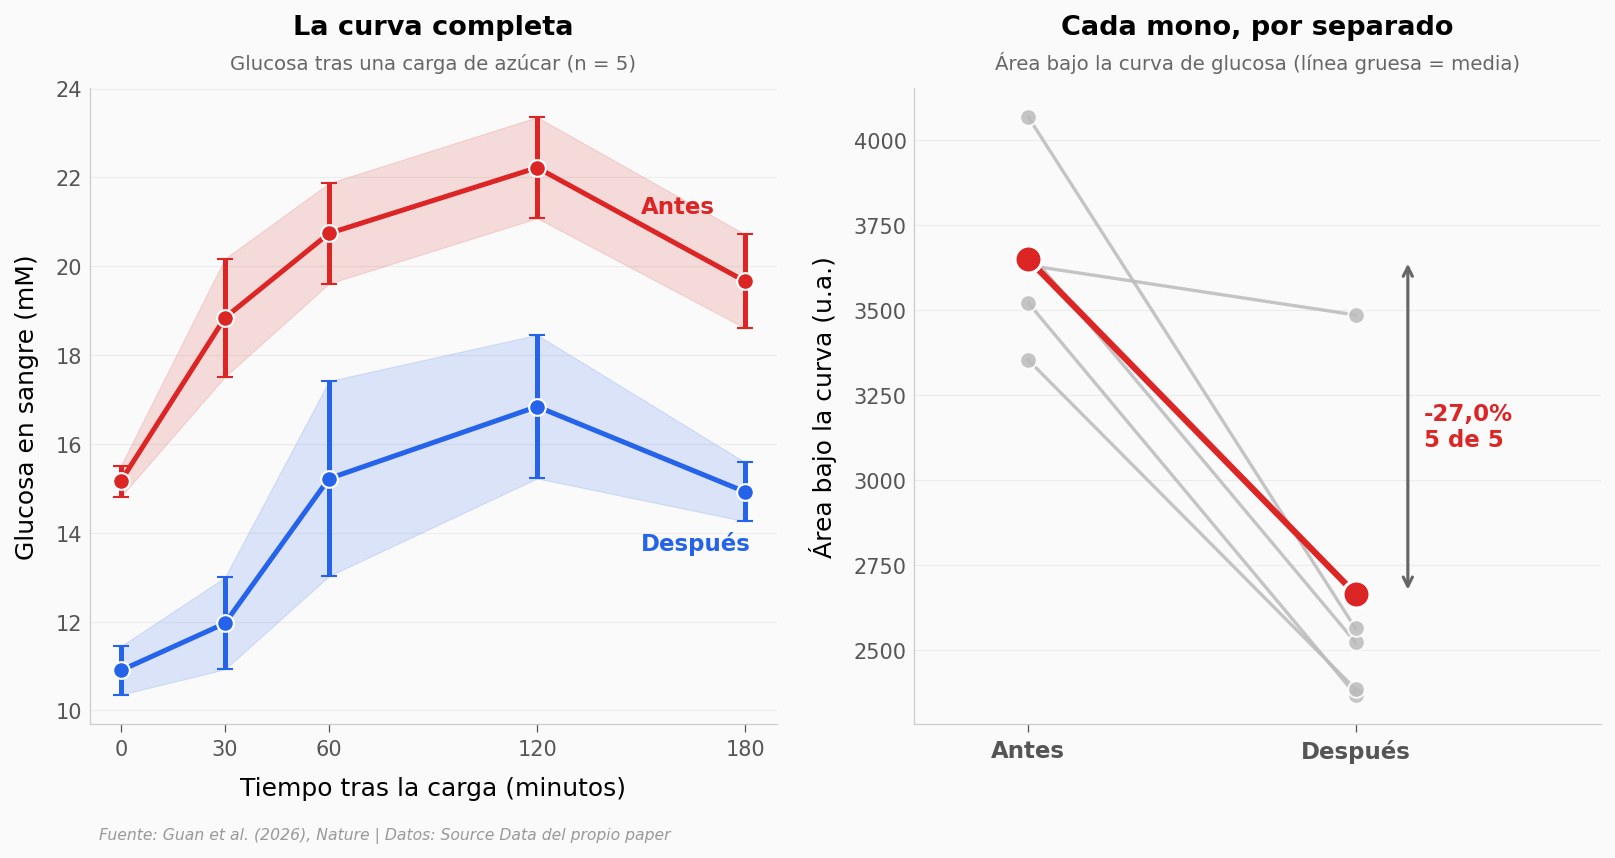

Área bajo la curva — mismos 5 monos, antes y después:
  Antes:   3649.2 ± 264.8
  Después: 2665.4 ± 466.5
  Cambio: -983.8 (-27.0%)  |  por mono: -1149, -1152, -146, -968, -1504
  d de Cohen pareado = 1.94  |  t pareado p = 0.0123

Pico de la curva: 22.22 mM antes -> 16.84 mM después


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Izquierda: curva de la prueba de azúcar ──
for fase, color in [('Antes', COLOR_ALERTA), ('Después', COLOR_DATOS)]:
    sub = ogtt[ogtt.fase == fase].groupby('tiempo_min').glucosa_mM.agg(['mean', 'sem'])
    ax1.errorbar(sub.index, sub['mean'], yerr=sub['sem'], fmt='o-', color=color,
                 markersize=8, linewidth=2.4, capsize=4, capthick=1.2,
                 markeredgecolor='white', markeredgewidth=1, zorder=5)
    ax1.fill_between(sub.index, sub['mean'] - sub['sem'], sub['mean'] + sub['sem'],
                     color=color, alpha=0.15, zorder=2)

ax1.text(150, 21.2, 'Antes', fontsize=11, color=COLOR_ALERTA, fontweight='bold')
ax1.text(150, 13.6, 'Después', fontsize=11, color=COLOR_DATOS, fontweight='bold')
ax1.set_title('La curva completa', fontsize=13, fontweight='bold', pad=26)
ax1.text(0.5, 1.03, 'Glucosa tras una carga de azúcar (n = 5)', transform=ax1.transAxes,
         fontsize=9.5, color='#666666', ha='center')
ax1.set_xlabel('Tiempo tras la carga (minutos)')
ax1.set_ylabel('Glucosa en sangre (mM)')
ax1.set_xticks([0, 30, 60, 120, 180])

# ── Derecha: área bajo la curva, mono por mono ──
piv_auc = auc.pivot(index='mono', columns='fase', values='auc_glucosa')
np.random.seed(42)
for mono in piv_auc.index:
    ax2.plot([0, 1], [piv_auc.loc[mono, 'Antes'], piv_auc.loc[mono, 'Después']],
             'o-', color=COLOR_CONTEXTO, markersize=8, linewidth=1.6, alpha=0.85,
             markeredgecolor='white', markeredgewidth=1, zorder=4)
ax2.plot([0, 1], [piv_auc['Antes'].mean(), piv_auc['Después'].mean()], 'o-',
         color=COLOR_ALERTA, markersize=13, linewidth=3,
         markeredgecolor='white', markeredgewidth=1.5, zorder=6)

cambio = 100 * (piv_auc['Después'].mean() - piv_auc['Antes'].mean()) / piv_auc['Antes'].mean()
ax2.annotate('', xy=(1.16, piv_auc['Después'].mean()), xytext=(1.16, piv_auc['Antes'].mean()),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax2.text(1.21, (piv_auc['Antes'].mean() + piv_auc['Después'].mean()) / 2,
         f'{cambio:.1f}%\n5 de 5'.replace('.', ','), fontsize=11, fontweight='bold',
         color=COLOR_ALERTA, va='center')

ax2.set_xlim(-0.35, 1.75)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Antes', 'Después'], fontsize=11, fontweight='bold')
ax2.set_title('Cada mono, por separado', fontsize=13, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, 'Área bajo la curva de glucosa (línea gruesa = media)',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.set_ylabel('Área bajo la curva (u.a.)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/monos_pareado.png', dpi=200, bbox_inches='tight')
plt.show()

dif_auc = piv_auc['Después'] - piv_auc['Antes']
print(f'Área bajo la curva — mismos 5 monos, antes y después:')
print(f'  Antes:   {piv_auc["Antes"].mean():.1f} ± {piv_auc["Antes"].std(ddof=1):.1f}')
print(f'  Después: {piv_auc["Después"].mean():.1f} ± {piv_auc["Después"].std(ddof=1):.1f}')
print(f'  Cambio: {dif_auc.mean():+.1f} ({cambio:+.1f}%)  |  por mono: '
      f'{", ".join(f"{int(x):+d}" for x in dif_auc.values)}')
print(f'  d de Cohen pareado = {abs(dif_auc.mean() / dif_auc.std(ddof=1)):.2f}  |  '
      f't pareado p = {stats.ttest_rel(piv_auc["Después"], piv_auc["Antes"]).pvalue:.4f}')
print(f'\nPico de la curva: {ogtt[ogtt.fase == "Antes"].groupby("tiempo_min").glucosa_mM.mean().max():.2f} mM antes '
      f'-> {ogtt[ogtt.fase == "Después"].groupby("tiempo_min").glucosa_mM.mean().max():.2f} mM después')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El sensor tiene un umbral: casi mudo hasta 5 mM, se dispara a 10 mM | ✅ | Salto de 9,9× entre 5 y 10 mM (0,299 → 2,951). ρ = 0,916, p = 5,6 × 10⁻⁹, n = 21 (3 réplicas × 7 concentraciones) |
| La respuesta satura: más azúcar ya no da más señal | ✅ | Meseta en 5,63 desde 15 mM; 25 mM (5,37) no supera a 20 mM (5,99) |
| El circuito se apaga y vuelve a encenderse | ⚠️ | Las dos secuencias van en espejo (ρ = −0,699, p = 0,0114) y ninguna se queda en su máximo. **Pero** el pie de figura está tras el muro de pago: no podemos verificar qué hora llevaba glucosa, así que no afirmamos el cronograma de encendido |
| El azúcar real sube la glucemia; el edulcorante no | ✅ | Cola +6,27 mM a los 15 min (d = 6,11; p = 0,0022). Cola dietética +0,43 mM, no separable del control (p = 0,1275). Chocolate +4,17 mM (d = 2,74) |
| El probiótico baja la glucosa en ayunas de los monos un 30% | ✅ | 15,16 → 10,57 mM (−4,59 mM, −30,3%). d pareado = 2,58; t pareado p = 0,0045. Los 5 de 5 bajan |
| El tratamiento normaliza la glucosa de los monos | ❌ | Terminan en 10,57 mM frente a 5,07 mM de los no diabéticos: **quedan 5,50 mM por encima**. Bajan, no normalizan |
| Manejan mejor una carga de azúcar | ✅ | Área bajo la curva 3.649 → 2.665 (−27,0%). d pareado = 1,94; t pareado p = 0,0123 — **idéntico al p que reporta el paper**. Pico 22,22 → 16,84 mM |
| Esto funciona en personas | ❌ | El paper no prueba nada en humanos. Está en su propio título: *in mice and monkeys* |

> **Limitaciones**
>
> - **Muestras pequeñas.** 5 monos y 6 ratones por grupo. Con n = 5, el Wilcoxon bilateral no puede dar menos de p = 0,0625 por construcción, sin importar qué tan grande sea el efecto. Por eso reportamos también el t pareado y los cambios individuales. Las diferencias por mono pasan la prueba de normalidad (Shapiro-Wilk: p = 0,76 en glucosa en ayunas y p = 0,27 en el área bajo la curva), así que el t pareado es el test apropiado — el mismo que el paper usa en el área bajo la curva (Tabla S16, Fig. 5j).
> - **El cuerpo del artículo está tras el muro de pago.** Trabajamos con el resumen, los pies de las figuras suplementarias, los datos fuente y la tabla estadística S16. Los números son los del propio equipo, pero no pudimos leer su interpretación.
> - **Dejamos fuera un panel.** En el archivo de datos de la señal por alimento, las columnas etiquetadas como control muestran la señal *más alta* del panel y las de chocolate casi ninguna — al revés de lo que muestra la glucemia. Sin el texto del paper no se resuelve, así que no lo graficamos.
> - **Dejamos fuera los ratones diabéticos.** En esas hojas el valor 34,0 mM se repite como techo del glucómetro (lecturas fuera de rango). Promediarlo subestimaría la hiperglucemia del grupo control.
> - **La sigla GIFT** que el equipo usa para nombrar el probiótico nunca se expande en el texto accesible. No inventamos qué significa.
> - **Los datos son del propio paper**, no de un repositorio independiente. Reproducen lo que el equipo publicó; no son una réplica externa.

## Ahora tú

**1. ¿Qué tanto del camino a la normalidad recorrió cada mono?**
Bajar 4,59 mM suena distinto si arrancas en 15 que si arrancas en 20. Prueba calculando, para cada mono, qué fracción de su distancia al valor sano cerró: `(basal - tratado) / (basal - GLUCOSA_SANOS_mM)`.

**2. ¿En qué momento de la curva ayuda más el probiótico?**
El área bajo la curva resume toda la prueba en un número y esconde dónde está la diferencia. Compara antes y después en cada tiempo por separado con `ogtt.groupby(['tiempo_min', 'fase'])` — ¿el efecto está en el pico o en el basal?

**3. ¿Habría alcanzado el azúcar de la Coca-Cola para encender el sensor?**
El sensor despierta cerca de 10 mM. Mira a qué valor llegaron los ratones con cola (`comida`) y compáralo con `UMBRAL_ACTIVACION_mM`. ¿Y con la dietética?

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué fracción de la distancia hasta el valor sano cerró cada mono?
# La "distancia" de cada mono es su propio basal menos la media de los no diabéticos.

trat = monos[monos.grupo == 'Diabéticos tratados']
basal_m = trat[trat.dia <= 0].groupby('mono').glucosa_mM.mean()
durante_m = trat[trat.dia >= DIA_INICIO_TRATAMIENTO].groupby('mono').glucosa_mM.mean()

recorrido = (basal_m - durante_m) / (basal_m - GLUCOSA_SANOS_mM) * 100

print(f'Referencia de los monos no diabéticos: {GLUCOSA_SANOS_mM} mM\n')
print(f'{"Mono":<7}{"basal":>8}{"tratado":>10}{"le falta":>11}{"camino recorrido":>19}')
for mono in basal_m.index:
    falta = durante_m[mono] - GLUCOSA_SANOS_mM
    print(f'{mono:<7}{basal_m[mono]:>8.2f}{durante_m[mono]:>10.2f}{falta:>11.2f}{recorrido[mono]:>18.1f}%')

print(f'\nMedia del camino recorrido: {recorrido.mean():.1f}%  '
      f'(rango: {recorrido.min():.1f}% a {recorrido.max():.1f}%)')
print(f'Ninguno llega al 100%: eso sería quedar en {GLUCOSA_SANOS_mM} mM.')

# Prueba cambiando GLUCOSA_SANOS_mM en la celda de configuración por el umbral
# clínico que prefieras y vuelve a correr: la lectura cambia bastante.

Referencia de los monos no diabéticos: 5.07 mM

Mono      basal   tratado   le falta   camino recorrido
1         15.60     11.98       6.91              34.3%
2         15.60      9.98       4.91              53.3%
3         16.17      9.64       4.57              58.8%
4         13.47     11.45       6.38              24.0%
5         14.97      9.81       4.74              52.1%

Media del camino recorrido: 44.5%  (rango: 24.0% a 58.8%)
Ninguno llega al 100%: eso sería quedar en 5.07 mM.


---

## Fuentes

**Paper**: [Glucose-responsive probiotics for glycaemic modulation in mice and monkeys](https://doi.org/10.1038/s41586-026-10909-6)  
*Nature, 2026-08-12 · paywall*

**Source Data**: [Source Data — Figs. 1, 3 y 5 (Glucose-responsive probiotics…)](https://doi.org/10.1038/s41586-026-10909-6)  
[Source Data — Extended Data Fig. 8 y Supplementary Table 16 (estadística detallada)](https://doi.org/10.1038/s41586-026-10909-6)  
*Datos numericos publicados por el equipo junto al articulo (mismo DOI)*

**Referencias citadas**: [BioProject PRJNA1023002 — 16S rRNA sequencing data](https://www.ncbi.nlm.nih.gov/bioproject/PRJNA1023002) — secuenciacion 16S depositada por el equipo; este notebook no la abre.

*16 afirmaciones verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com) — El Lab.
Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)*